# Notebook 2 — Generazione del modello bayesiano source (MNIST)

**Concetto (paper U-SFAN, Sec. 3.1).** Il modello è $f=h\circ g$:
- $g$ = feature extractor (una CNN, parametri $\beta$) → resta **deterministico e congelato**;
- $h$ = ultimo layer lineare (parametri $\theta$) → riceve il **trattamento bayesiano**.

Mettiamo una Gaussiana sui pesi della **sola testa**: la *last-layer Laplace*
$\;q(\theta)=\mathcal N(\theta_{\text{MAP}},H^{-1})$, con $H=\sum_n \Lambda_n\otimes\phi_n\phi_n^{\top}+\tau I$
— **esattamente** l'Hessiana costruita e verificata nel Notebook 1, dove ora le $\phi_n=g(x_n)$
vengono dalla CNN invece che da feature grezze.

**"Source-free".** La source (MNIST) serve **una sola volta**, qui, per un singolo forward
pass che costruisce $H$. Dopo il fit la posterior è autosufficiente e la source si può scartare.

**Prova di comprensione (obiettivo).** (1) generare il modello bayesiano source su MNIST;
(2) validare la Laplace contro la posterior **vera** via MCMC su un problema piccolo:
mostrare che l'approssimazione *regge* e — punto cruciale — *quando non regge*.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # evita OMP Error #15 (Windows)

import sys, pathlib
# root del progetto = cartella che contiene 'src', trovata a partire dal notebook
here = pathlib.Path.cwd()
for base in [here, *here.parents]:
    if (base / "src").is_dir():
        sys.path.insert(0, str(base)); PROJ = base; break
else:
    raise RuntimeError("cartella 'src' non trovata: apri il progetto dalla sua root")
import numpy as np, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import torchvision, torchvision.transforms as T

from src.bayesian_model import (
    SmallCNN, train_map, extract, head_weights, augment,
    LastLayerLaplace, mcmc_posterior, _entropy,
)
from src.laplace_core import softmax

torch.manual_seed(0); np.random.seed(0)
DEVICE = "cpu"


## 1. Source = MNIST: training del modello a MAP

Alleniamo la CNN sulla source (MNIST) con cross-entropy + weight decay. Il weight
decay **è** il prior gaussiano sui pesi: restituisce `tau_prior = weight_decay · N`,
la precisione del prior sulla scala della verosimiglianza sommata (Notebook 1).
Usiamo un sottoinsieme per rapidità — con tutto MNIST i numeri migliorano ma la storia
è identica.

In [2]:
tf = T.ToTensor()
mnist_tr = torchvision.datasets.MNIST(str(PROJ / "data"), train=True,  download=True, transform=tf)
mnist_te = torchvision.datasets.MNIST(str(PROJ / "data"), train=False, download=True, transform=tf)

tr = Subset(mnist_tr, range(20000))   # source pool
te = Subset(mnist_te, range(2000))
train_loader = DataLoader(tr, batch_size=128, shuffle=True)
src_loader   = DataLoader(tr, batch_size=1024)   # per estrarre le feature source
test_loader  = DataLoader(te, batch_size=1024)

model = SmallCNN(n_classes=10)
tau_prior = train_map(model, train_loader, epochs=3, lr=1e-3, weight_decay=1e-3,
                      device=DEVICE, log_every=0)
print(f"tau_prior = weight_decay * N = {tau_prior:.1f}")

model.eval(); correct = total = 0
with torch.no_grad():
    for x, y in test_loader:
        correct += (model(x).argmax(1) == y).sum().item(); total += len(y)
print(f"accuratezza source (MNIST test): {correct/total:.3f}")

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/9912422 [00:00<?, ?it/s]

  0%|          | 32768/9912422 [00:00<00:37, 266510.54it/s]

  1%|          | 65536/9912422 [00:00<00:34, 288449.77it/s]

  1%|          | 98304/9912422 [00:00<00:37, 260421.62it/s]

...

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/4542 [00:00<?, ?it/s]

100%|██████████| 4542/4542 [00:00<00:00, 2570574.65it/s]

Extracting /Users/riccardo/Desktop/PML/BayesianExoAdaptation/code_v2/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /Users/riccardo/Desktop/PML/BayesianExoAdaptation/code_v2/data/MNIST/raw



tau_prior = weight_decay * N = 20.0
accuratezza source (MNIST test): 0.967


## 2. Congelo $g$, estraggo le feature, fitto la last-layer Laplace

Il feature extractor ora è congelato. Estraiamo $\phi=g(x)$ sulle immagini source,
aumentiamo con la colonna di bias, e costruiamo la posterior $\mathcal N(\theta_{\text{MAP}},H^{-1})$
sulla testa. **Da qui in poi la source non serve più.**

In [3]:
Phi, Y, _ = extract(model, src_loader, device=DEVICE)   # feature source (numpy)
Phi_aug = augment(Phi)                                   # (N, 129)
W_aug   = head_weights(model)                            # (10, 129) testa MAP + bias

laplace = LastLayerLaplace.fit(W_aug, Phi_aug, tau_prior=tau_prior)
print(f"posterior sulla testa: θ_MAP {laplace.theta_map.shape}, "
      f"cov {laplace.cov.shape}  (K={laplace.K}, Dp={laplace.Dp})")

eig = np.linalg.eigvalsh(laplace.cov)
print(f"covarianza PSD: {(eig > 0).all()}  (autovalori in [{eig.min():.1e}, {eig.max():.1e}])")

# campionare teste dalla posterior funziona:
sample = laplace.sample_heads(M=5, rng=np.random.default_rng(0))
print(f"5 campioni θ ~ N(θ_MAP, cov): shape {sample.shape}")

posterior sulla testa: θ_MAP (1290,), cov (1290, 1290)  (K=10, Dp=129)


covarianza PSD: True  (autovalori in [4.9e-06, 5.0e-02])
5 campioni θ ~ N(θ_MAP, cov): shape (5, 1290)


> A questo punto abbiamo un **modello bayesiano source** completo: testa MAP +
> posterior. La source (MNIST) può essere scartata; tutto ciò che serve per quantificare
> l'incertezza è nella coppia (feature extractor congelato, posterior della testa).

## 3. Validazione: Laplace vs posterior vera (MCMC)

La Laplace è un'approssimazione locale (Notebook 0). Regge? La testa reale ha 1290
parametri: MCMC lì è inutile. Ma il **concetto** si valida su un problema piccolo e
tracciabile: un modello lineare softmax (K=3, D=2 → 9 parametri) su cui possiamo
campionare la posterior **vera** con Metropolis-Hastings e confrontarla con la Laplace.

Idea da dimostrare (Bernstein–von Mises): **la Laplace è asintoticamente esatta al
crescere di N**. Con pochi dati la posterior è non-gaussiana e la Laplace sbaglia; con
più dati converge alla Gaussiana.

In [4]:
def make_blobs(N, seed, K=3, D=2, spread=0.7):
    r = np.random.default_rng(seed)
    centers = r.normal(size=(K, D)) * 2.5
    X = np.concatenate([centers[k] + r.normal(size=(N//K, D))*spread for k in range(K)])
    y = np.concatenate([np.full(N//K, k) for k in range(K)])
    return X, y

def fit_map_linear(Phi, y, K, tau, iters=800, lr=0.4):
    N, Dp = Phi.shape
    W = np.zeros((K, Dp))
    for _ in range(iters):
        P = softmax(Phi @ W.T)
        G = (P - np.eye(K)[y]).T @ Phi / N + (tau/N) * W
        W -= lr * G
    return W

def compare(N, seed=2, K=3):
    X, y = make_blobs(N, seed, K)
    Phi = augment(X); tau = 1e-2 * N
    W = fit_map_linear(Phi, y, K, tau)
    lap = LastLayerLaplace.fit(W, Phi, tau_prior=tau)
    # punti di test indipendenti
    Xt, _ = make_blobs(30, 99, K); Pt = augment(Xt)
    lp = lap.predictive(Pt, M=2000, rng=np.random.default_rng(0))
    # posterior VERA via MCMC + predittiva MC dalla posterior vera
    samp, acc = mcmc_posterior(Phi, y, K, tau, n_samples=6000, burn_in=2000, step=0.08,
                               rng=np.random.default_rng(0))
    th = samp.reshape(-1, K, Phi.shape[1])
    pm = softmax(np.einsum("mkd,nd->mnk", th, Pt))
    mc_prob = pm.mean(0)
    return dict(N=N, lap=lp, mc_prob=mc_prob, mc_tot=_entropy(mc_prob),
                samp=samp, acc=acc, W=W, lapobj=lap)

print(f"{'N':>5} | corr(prob) | corr(entropia totale) | accept")
res = {}
for N in [30, 150]:
    r = compare(N); res[N] = r
    cp = np.corrcoef(r["lap"]["probs"].ravel(), r["mc_prob"].ravel())[0,1]
    ce = np.corrcoef(r["lap"]["total"], r["mc_tot"])[0,1]
    print(f"{N:>5} | {cp:10.3f} | {ce:21.3f} | {r['acc']:.2f}")

    N | corr(prob) | corr(entropia totale) | accept
   30 |      0.941 |                 0.914 | 0.86


  150 |      0.975 |                 0.973 | 0.65


### "Quando regge / quando no": la forma della posterior

Il confronto numerico non basta: guardiamo **la forma** di una marginale della posterior.
Con pochi dati (N=30) la posterior vera (istogramma MCMC) è asimmetrica e la Gaussiana
di Laplace la manca; con più dati (N=150) le due si sovrappongono — la Laplace è
asintoticamente corretta.

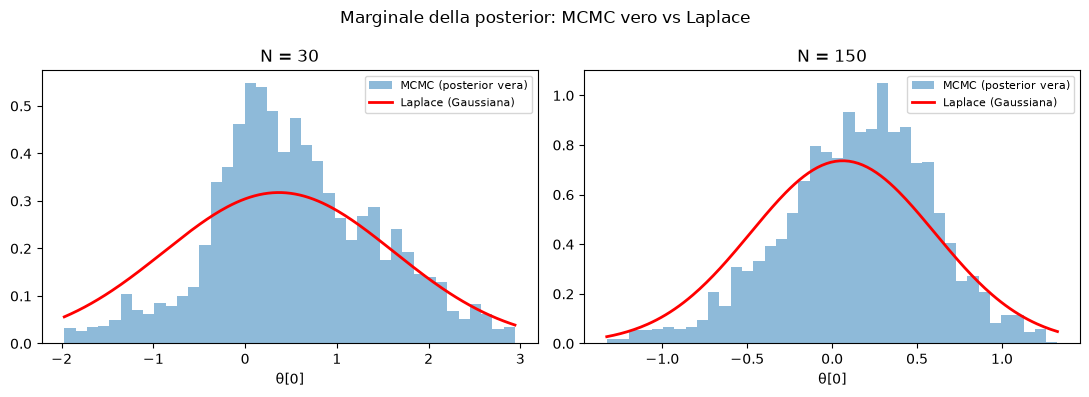

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, N in zip(axes, [30, 150]):
    r = res[N]
    j = 0  # una componente qualsiasi dei pesi
    mc = r["samp"][:, j]
    mu = r["lapobj"].theta_map[j]
    sd = np.sqrt(r["lapobj"].cov[j, j])
    ax.hist(mc, bins=40, density=True, alpha=.5, label="MCMC (posterior vera)")
    zz = np.linspace(mc.min(), mc.max(), 200)
    ax.plot(zz, np.exp(-0.5*((zz-mu)/sd)**2)/(sd*np.sqrt(2*np.pi)), "r-", lw=2,
            label="Laplace (Gaussiana)")
    ax.set_title(f"N = {N}"); ax.set_xlabel("θ[0]"); ax.legend(fontsize=8)
fig.suptitle("Marginale della posterior: MCMC vero vs Laplace")
fig.tight_layout(); plt.show()

## Riassunto

- Abbiamo **generato il modello bayesiano source** su MNIST: CNN congelata + last-layer
  Laplace, riusando l'Hessiana del Notebook 1. La source è ora scartabile (*source-free*).
- La Laplace, validata contro MCMC, **regge** e **migliora con N** (Bernstein–von Mises);
  con pochi dati o posterior non-gaussiana **non regge** — limite locale già visto nel NB0.

Nel Notebook 3 usiamo questa posterior per **decomporre** l'incertezza (BALD) e isolare
il segnale che, nei notebook successivi, rivelerà lo shift di dominio.

Salviamo gli artefatti per il notebook 3.

In [6]:
import os
os.makedirs(str(PROJ / "data"), exist_ok=True)
torch.save(model.state_dict(), str(PROJ / "data" / "mnist_cnn.pt"))
np.savez(str(PROJ / "data" / "mnist_laplace.npz"),
         theta_map=laplace.theta_map, cov=laplace.cov, K=laplace.K, Dp=laplace.Dp,
         tau_prior=tau_prior)
print("salvati in", PROJ / "data", ": mnist_cnn.pt , mnist_laplace.npz")

salvati in /Users/riccardo/Desktop/PML/BayesianExoAdaptation/code_v2/data : mnist_cnn.pt , mnist_laplace.npz
